In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load processed data
df = pd.read_csv("data/output/training_data.csv")

# Features / target
X = df.drop("student_status", axis=1)
y = df["student_status"]

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, y_train.shape)
print("Val:", X_val_scaled.shape, y_val.shape)
print("Test:", X_test_scaled.shape, y_test.shape)
print("Classes:", sorted(df["student_status"].unique()))

Train: (3373, 10) (3373,)
Val: (723, 10) (723,)
Test: (723, 10) (723,)
Classes: [np.int64(0), np.int64(1), np.int64(2)]


In [3]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=10
)

mlp_model.fit(X_train_scaled, y_train)

print("Training complete.")
print("Iterations used:", mlp_model.n_iter_)
print("Final training loss:", mlp_model.loss_)

Training complete.
Iterations used: 25
Final training loss: 0.5622820686984051


Neural Network Accuracy: 0.7275242047026279
Neural Network Macro F1: 0.6649744399300566
Neural Network Weighted F1: 0.7170597664558378

Classification Report:

              precision    recall  f1-score   support

     Dropout       0.80      0.67      0.73       232
    Enrolled       0.49      0.39      0.43       148
    Graduate       0.76      0.91      0.83       343

    accuracy                           0.73       723
   macro avg       0.68      0.66      0.66       723
weighted avg       0.72      0.73      0.72       723

Confusion Matrix:
 [[156  36  40]
 [ 33  58  57]
 [  6  25 312]]


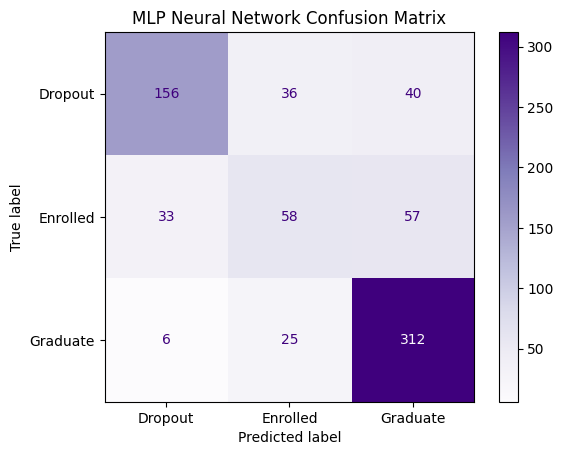


Accuracy Comparison:
Logistic Regression: 0.7026
Random Forest: 0.7165
MLP Neural Network: 0.7275242047026279

Saved: mlp_model.pkl and scaler.pkl


In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Predict
y_pred_nn = mlp_model.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Neural Network Macro F1:", f1_score(y_test, y_pred_nn, average='macro'))
print("Neural Network Weighted F1:", f1_score(y_test, y_pred_nn, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_nn,
    target_names=["Dropout", "Enrolled", "Graduate"]
))

# Confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
print("Confusion Matrix:\n", cm_nn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=["Dropout", "Enrolled", "Graduate"]
)
disp.plot(cmap="Purples")
plt.title("MLP Neural Network Confusion Matrix")
plt.show()

# Compare with baseline values from Report 1
print("\nAccuracy Comparison:")
print("Logistic Regression:", 0.7026)
print("Random Forest:", 0.7165)
print("MLP Neural Network:", accuracy_score(y_test, y_pred_nn))

# Save model + scaler
joblib.dump(mlp_model, "mlp_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nSaved: mlp_model.pkl and scaler.pkl")